In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
# # open fema nri data
# nri = pd.read_csv("../data/raw/FEMA_NRI/NRI_Table_censusTracts.csv")
# # extract only vermont data
# nri_vt = nri[nri["STATE"] == "Vermont"]
# len(nri_vt)
# # save to csv
# nri_vt.to_csv("../data/raw/FEMA_NRI/nri_vt.csv", index=False)

# open vt fema nri data
# nri_vt = pd.read_csv("../data/raw/FEMA_NRI/nri_vt.csv")
# nri_vt.columns

In [3]:
# open shapefile
fp = "../data/raw/census_shp/tl_2025_50_cousub.shp"
gdf_census = gpd.read_file(fp)

# prune to only include relevant columns
gdf_census = gdf_census[["GEOID", "NAME", "NAMELSAD", "ALAND", "AWATER", "geometry"]]

# # rename columns for clarity
# gdf_census = gdf_census.rename(columns={"NAMELSAD": "town_name"})
# print(gdf_census.columns)

# convert to equal-area CRS for accurate area calculations
gdf_census = gdf_census.to_crs("EPSG:5070")

# check projection
print(gdf_census.crs)

EPSG:5070


In [4]:
# open fema nri shapefile
nri_gdf = gpd.read_file(
    "../data/raw/FEMA_NRI/NRI_Shapefile_CensusTracts/NRI_Shapefile_CensusTracts.shp"
)
nri_vt_gdf = nri_gdf[nri_gdf["STATE"] == "Vermont"]
len(nri_vt_gdf)

193

In [5]:
# check projection
print(nri_vt_gdf.crs)

# convert to equal-area CRS for accurate area calculations
nri_vt_gdf = nri_vt_gdf.to_crs("EPSG:5070")

# check projection again
print(nri_vt_gdf.crs)

EPSG:3857
EPSG:5070


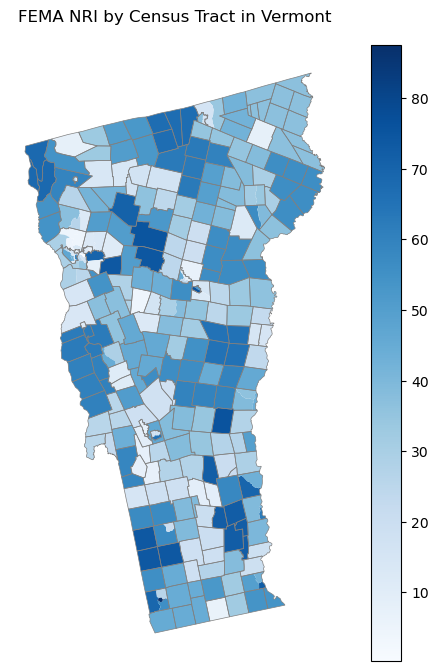

In [6]:
# plot FEMA NRI over town boundaires
ax = gdf_census.boundary.plot(figsize=(8, 8), color="gray", linewidth=0.5)
nri_vt_gdf.plot(ax=ax, column="RISK_SCORE", cmap="Blues", legend=True)
ax.set_title("FEMA NRI by Census Tract in Vermont")
ax.set_axis_off()
plt.show()

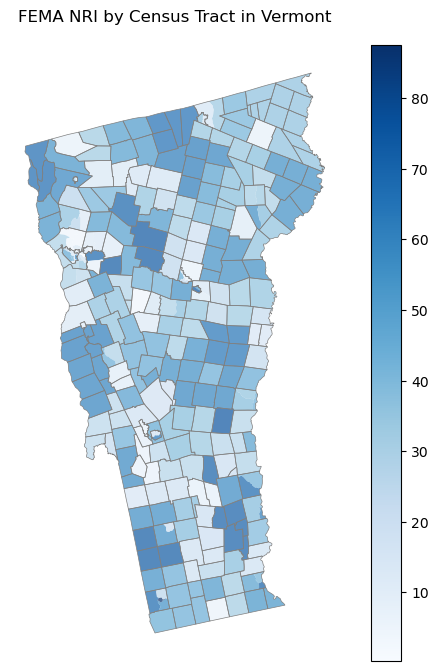

In [7]:
# overlap the two datasets to see how they align
fig, ax = plt.subplots(figsize=(8, 8))
gdf_census.boundary.plot(ax=ax, color="gray", linewidth=0.5)
nri_vt_gdf.plot(ax=ax, column="RISK_SCORE", cmap="Blues", legend=True, alpha=0.7)
ax.set_title("FEMA NRI by Census Tract in Vermont")
ax.set_axis_off()
plt.show()

In [8]:
# overlay FEMA NRI on town boundaries
intersected = gpd.overlay(gdf_census, nri_vt_gdf, how="intersection")

In [9]:
# # calculate overlap area
# intersected["overlap_area"] = intersected.geometry.area

# # calculate percentage of town area that overlaps with each NRI tract
# intersected["overlap_pct"] = intersected["overlap_area"] / intersected["ALAND"]
# # display results
# print(intersected[["GEOID", "NAME", "RISK_SCORE", "overlap_pct"]])

In [10]:
# calculate area of intersection
intersected["area_intersect"] = intersected.geometry.area

# total area of each tract
tract_areas = nri_vt_gdf[["TRACTFIPS", "geometry"]].copy()
tract_areas["area_tract"] = tract_areas.geometry.area

# merge back
intersected = intersected.merge(
    tract_areas[["TRACTFIPS", "area_tract"]], on="TRACTFIPS", how="left"
)

# weight = % of tract in town
intersected["weight"] = intersected["area_intersect"] / intersected["area_tract"]

# filter out very small overlaps, slivers toeing over boundaries
intersected = intersected[intersected["weight"] > 0.01]

intersected["weight"].describe()

count    307.000000
mean       0.628409
std        0.353343
min        0.020400
25%        0.293946
50%        0.523520
75%        0.999706
max        1.000000
Name: weight, dtype: float64

In [11]:
# apply weighting to NRI variables and aggregate by town
nri_vars = [
    "RISK_SCORE",  # National Risk Index score, normalized 0-100
    "SOVI_SCORE",  # Social Vulnerability Index score, normalized 0-100
    "IFLD_RISKS",  # flood risk score, normalized 0-100
    "IFLD_EALT",  # expected annual loss from flooding, in dollars
    "IFLD_EALP",  # expected annual loss in population from flooding (fatalities and injuries, injuries 1/10th of a fatality)
    "IFLD_EALPE",  # expected annual loss in population, in equivalent dollars
    "IFLD_EALB",  # expected annual loss to buildings from flooding
    "IFLD_EALA",  # expected annual loss to agriculture from flooding
    # "EAL_VALT", # total expected annual loss
    # "EAL_VALB", # expected annual loss to buildings
    # "EAL_VALP", # expected annual loss to population
    # "EAL_VALA", # expected annual loss to agriculture
    "RESL_SCORE",  # resilience score, normalized 0-100
    "CRF_VALUE",  # Community Risk Factor score, normalized 0-100
    "POPULATION",  # population of tract
    "BUILDVALUE",  # total building value in tract, in dollars
    "AGRIVALUE",  # total agricultural value in tract, in dollars
    "AREA",  # area of tract in square miles
]

# apply weights
for col in nri_vars:
    intersected[f"{col}_weighted"] = intersected[col] * intersected["weight"]

# aggregate by town
# TODO: remove normalized scores and just sum the raw values, then re-normalize at the town level
# i.e., RISK_SCORE, SOVI_SCORE, IFLD_RISKS, RESL_SCORE, and CRF_VALUE
town_nri = (
    intersected.groupby(["GEOID", "NAMELSAD", "ALAND"])[
        [f"{col}_weighted" for col in nri_vars]
    ]
    .sum()
    .reset_index()
)

In [12]:
town_nri["ALAND_sqmi"] = town_nri["ALAND"] / 2_589_988.110336
town_nri.head()

,GEOID,NAMELSAD,ALAND,RISK_SCORE_weighted,SOVI_SCORE_weighted,IFLD_RISKS_weighted,IFLD_EALT_weighted,IFLD_EALP_weighted,IFLD_EALPE_weighted,IFLD_EALB_weighted,IFLD_EALA_weighted,RESL_SCORE_weighted,CRF_VALUE_weighted,POPULATION_weighted,BUILDVALUE_weighted,AGRIVALUE_weighted,AREA_weighted,ALAND_sqmi
0,5000100325,Addison town,107710362,21.911899,15.201908,29.261151,442912.614134,0.000115,1575.714331,437359.681606,3977.218196,25.939996,0.375436,1741.467675,6.778435e+08,2.320784e+07,49.473296,41.587203
1,5000108575,Bridport town,113158876,15.113098,13.341647,19.340986,248249.152814,0.000062,850.256973,244542.440039,2856.455803,18.495432,0.287754,1337.175492,4.317067e+08,2.239080e+07,46.740959,43.690886
2,5000109025,Bristol town,105018080,35.957618,41.888641,63.954245,801157.708509,0.000357,4897.600352,795030.634886,1229.473271,73.777174,1.057557,3781.229659,9.089175e+08,5.315462e+06,41.630627,40.547707
3,5000116000,Cornwall town,73990773,9.385580,8.285468,12.011195,154168.406012,0.000039,528.029041,151866.452536,1773.924434,11.486086,0.178702,830.416587,2.680998e+08,1.390520e+07,29.027205,28.567997
4,5000126300,Ferrisburgh town,122981519,13.917088,9.207729,34.042533,655532.284372,0.000173,2376.214529,650637.787256,2518.282587,73.775163,0.723942,2645.388928,8.611911e+08,2.304077e+07,61.809171,47.483430


In [13]:
len(town_nri)

255

In [14]:
intersected.groupby("GEOID")["weight"].sum().describe()

count    255.000000
mean       0.756555
std        0.999925
min        0.028027
25%        0.261937
50%        0.490546
75%        0.999712
max       10.995321
Name: weight, dtype: float64